<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [45]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

dataset = load_iris()
x = dataset.data
y = dataset.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(x_train, y_train)

acuracia_treino = accuracy_score(y_train, modelo.predict(x_train))
acuracia_teste = accuracy_score(y_test, modelo.predict(x_test))

print(f"Acurácia no treino: {acuracia_treino:.2f}")
print(f"Acurácia no teste:  {acuracia_teste:.2f}")

Acurácia no treino: 1.00
Acurácia no teste:  1.00


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

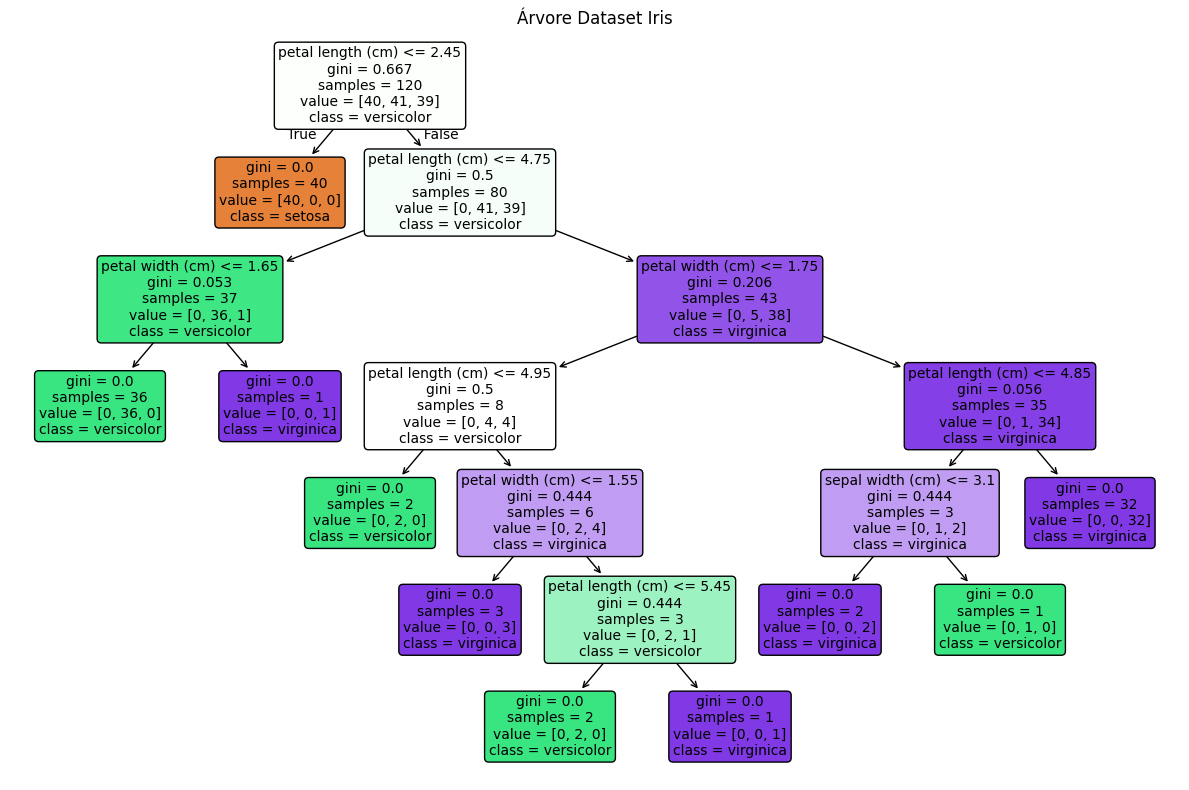

In [47]:
from sklearn.tree import plot_tree
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 8))
plot = plot_tree(modelo, filled=True)
plot_tree(
    modelo,
    feature_names=dataset.feature_names,
    class_names=dataset.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árvore Dataset Iris")
plt.tight_layout()
plt.show()

Respostas:

A árvore tem profundidade *6* e o atribito da raiz é o "petal lenght"

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [48]:
import pandas as pd

depths = list(range(1, 10)) + [None]
resultados = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(x_train, y_train)
    
    acuracia_treino = accuracy_score(y_train, clf.predict(x_train))
    accacuracia_teste  = accuracy_score(y_test,  clf.predict(x_test))
    
    resultados.append({
        "max_depth":        str(depth) if depth else "None",
        "Acurácia Treino":  f"{acuracia_treino*100:.1f}%",
        "Acurácia Teste":   f"{accacuracia_teste*100:.1f}%",
        "Profundidade Real": clf.get_depth(),
        "Número de Folhas":     clf.get_n_leaves()
    })

df = pd.DataFrame(resultados)
print(df.to_string(index=False))

max_depth Acurácia Treino Acurácia Teste  Profundidade Real  Número de Folhas
        1           67.5%          63.3%                  1                 2
        2           95.0%          96.7%                  2                 3
        3           95.8%         100.0%                  3                 5
        4           97.5%         100.0%                  4                 7
        5           99.2%         100.0%                  5                 9
        6          100.0%         100.0%                  6                10
        7          100.0%         100.0%                  6                10
        8          100.0%         100.0%                  6                10
        9          100.0%         100.0%                  6                10
     None          100.0%         100.0%                  6                10


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

A partir do max_depth 6 começa o overfitting por conta da acurácia de treino 100%

No max_depth = none a árvore cresce livremente até que cada folha tenha apenas nós puros, gerando overfitting

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [49]:
criterions = ["gini", "entropy"]
resultados = []

for criterion in criterions:
    clf = DecisionTreeClassifier(criterion=criterion, random_state=42)
    clf.fit(x_train, y_train)
    
    acuracia_treino = accuracy_score(y_train, clf.predict(x_train))
    accacuracia_teste  = accuracy_score(y_test,  clf.predict(x_test))
    
    resultados.append({
        "Critério":          criterion,
        "Profundidade":      clf.get_depth(),
        "Acurácia Treino":   f"{acuracia_treino*100:.1f}%",
        "Acurácia Teste":    f"{accacuracia_teste*100:.1f}%",
    })

df = pd.DataFrame(resultados)
print(df.to_string(index=False))

Critério  Profundidade Acurácia Treino Acurácia Teste
    gini             6          100.0%         100.0%
 entropy             6          100.0%         100.0%


Nos dois casos os resultados foram identicos, o critério de divisão não faz diferença na prática

# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

max_depth  Acurácia Treino  Acurácia Teste  Profundidade Real  Número de Folhas
        1         0.675000        0.633333                  1                 2
        2         0.950000        0.966667                  2                 3
        3         0.958333        1.000000                  3                 5
        4         0.975000        1.000000                  4                 7
        5         0.991667        1.000000                  5                 9
        6         1.000000        1.000000                  6                10
        7         1.000000        1.000000                  6                10
        8         1.000000        1.000000                  6                10
        9         1.000000        1.000000                  6                10
     None         1.000000        1.000000                  6                10

   Melhor modelo: max_depth = 3
   Acurácia Treino:  0.9583
   Acurácia Teste:   1.0000
   Profundidade Real: 3
   Núme

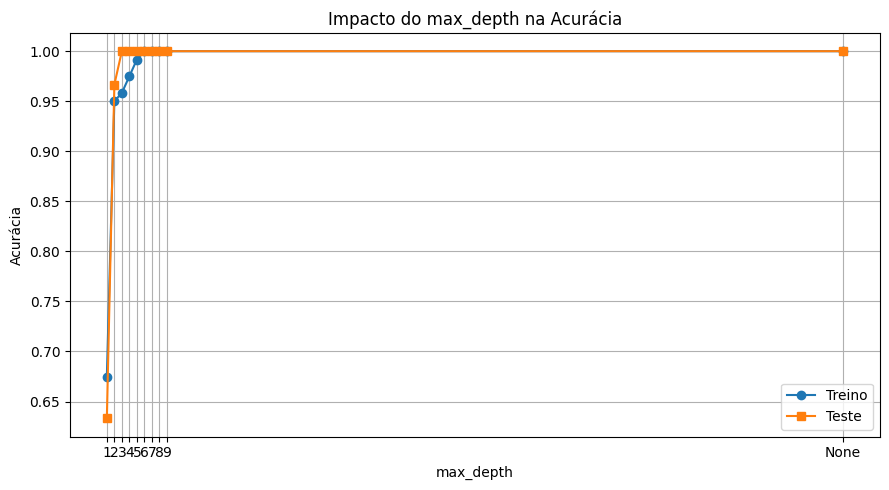

In [50]:
depths = list(range(1, 10)) + [None]
resultados = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(x_train, y_train)
    
    acc_train = accuracy_score(y_train, clf.predict(x_train))
    acc_test  = accuracy_score(y_test,  clf.predict(x_test))
    
    resultados.append({
        "max_depth":        depth if depth else 99,
        "label":            str(depth) if depth else "None",
        "Acurácia Treino":  acc_train,
        "Acurácia Teste":   acc_test,
        "Profundidade Real": clf.get_depth(),
        "Número de Folhas":     clf.get_n_leaves()
    })

df = pd.DataFrame(resultados)

print(df[["label","Acurácia Treino","Acurácia Teste","Profundidade Real","Número de Folhas"]]
      .rename(columns={"label": "max_depth"})
      .to_string(index=False))

best = df[df["Acurácia Teste"] == df["Acurácia Teste"].max()].iloc[0]
print(f"\n   Melhor modelo: max_depth = {best['label']}")
print(f"   Acurácia Treino:  {best['Acurácia Treino']:.4f}")
print(f"   Acurácia Teste:   {best['Acurácia Teste']:.4f}")
print(f"   Profundidade Real: {int(best['Profundidade Real'])}")
print(f"   Número de Folhas:      {int(best['Número de Folhas'])}")

plt.figure(figsize=(9, 5))
plt.plot(df["max_depth"], df["Acurácia Treino"], marker="o", label="Treino")
plt.plot(df["max_depth"], df["Acurácia Teste"],  marker="s", label="Teste")
plt.xticks(df["max_depth"], df["label"])
plt.xlabel("max_depth")
plt.ylabel("Acurácia")
plt.title("Impacto do max_depth na Acurácia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

O melhor modelo a ser escolhido é o max_depth = 3 por não estar com overfitting e nem underfitting, sendo um meio termo em relação às outras profundidades